# 🏙️ Análise Exploratória de Dados: Apartamentos à Venda em São Paulo

**Aluno(a):** Daniele Souza das Virgens  
**Disciplina:** Ciência de Dados e Aprendizado de Máquina  
**Instituição:** Universidade Estadual de Feira de Santana


---

## 📊 <h1>Introdução</h1><hr>

Este trabalho tem como objetivo realizar uma **análise descritiva e exploratória** de um conjunto de dados sobre **apartamentos à venda na cidade de São Paulo**, com foco em fornecer informações relevantes para **compradores, vendedores e gestores municipais**.

O conjunto de dados foi **fornecido previamente pelo professor** e contém informações obtidas por meio de **web scraping**, complementadas com **análise espacial** e enriquecidas com **indicadores socioeconômicos** dos bairros, como:
- Distância até a estação de metrô mais próxima;
- Índice de Desenvolvimento Humano (IDH);
- Expectativa de vida;
- Renda per capita;
- Entre outras variáveis georreferenciadas (latitude e longitude).

Durante a análise, foram aplicadas ferramentas analíticas como:
- **Identificação dos tipos de dados**;
- **Estatísticas descritivas** de centralidade (média, mediana) e dispersão (desvio padrão, mínimo, máximo);
- **Análise de frequências**;
- **Comparações entre bairros**;
- E **visualizações gráficas** para explorar relações entre variáveis, como valor do imóvel, área útil, infraestrutura e proximidade ao transporte público.

Vale destacar que, conforme informado, **parte dos dados pode conter valores inconsistentes**, já que foram obtidos via scraping e **não passaram por tratamento completo de limpeza**. Esse aspecto foi considerado nas etapas da análise e visualização.

Ao final do trabalho, apresento um **resumo com os principais insights** encontrados, com o objetivo de subsidiar tomadas de decisão mais conscientes no setor imobiliário e apoiar políticas públicas voltadas à moradia urbana.


<br><h2>👩‍💻 Instalações</h2><hr>

In [71]:
!pip install pandas

In [9]:
import pandas as pd

In [12]:
import numpy as np

In [15]:
pip install matplotlib seaborn pandas

Note: you may need to restart the kernel to use updated packages.


In [35]:
# Ativa exibição inline (exibe o gráfico no notebook)
%matplotlib inline

# Importa bibliotecas
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo
sns.set_style("whitegrid")


<br><br>

<h2>Carregar Database</h2><hr>

In [41]:
# Recarregar o CSV usando encoding e separador corretos
data = pd.read_csv("./dados_reduzidos - dados_reduzidos.csv", encoding="utf-8", sep=",")

# Agora faz a conversão das colunas numéricas com vírgula
colunas_para_converter = ["dist", "lat", "lon", "renda_percapita", "media_idh", "expectativa_vida"]

for col in colunas_para_converter:
    data[col] = data[col].astype(str).str.replace(",", ".").astype(float)

# Verificar se a coluna dist foi carregada corretamente
print(data["dist"].describe())


count     2499.000000
mean      2850.631882
std       2740.544877
min         31.324895
25%        926.379634
50%       2030.330924
75%       3844.249552
max      26101.126560
Name: dist, dtype: float64


In [42]:
data

,id,valor_total,area_util,quartos,vagas,valor_condominio,suites,banheiros,piscina,academia,...,bairro,qtd_dados_bairro,media_idh,expectativa_vida,renda_percapita,estacao_prox,linha_prox,dist,lat,lon
0,526,189900,32,2,1,180.0,0,1,0,1,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,SÃO MATEUS,PRATA,6822.823684,-23.583879,-46.417548
1,734,221110,43,2,1,250.0,0,1,0,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4682.709841,-23.543535,-46.425492
2,738,219990,43,1,1,300.0,0,1,1,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
3,753,219990,43,2,1,300.0,0,1,1,0,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,4579.311123,-23.537339,-46.426823
4,924,220000,41,2,1,300.0,0,1,1,1,...,JOSE BONIFACIO,36.0,0.697182,72.751818,559.668182,CORINTHIANS-ITAQUERA,VERMELHA,3313.918703,-23.557799,-46.443523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2494,2232,400000,61,1,0,NaN,0,1,0,0,...,REPUBLICA,17.0,0.839667,79.776667,1691.543333,REPÚBLICA,AMARELA,517.307020,-23.549233,-46.644282
2495,2233,688000,146,2,1,600.0,1,3,0,0,...,REPUBLICA,17.0,0.839667,79.776667,1691.543333,REPÚBLICA,AMARELA,452.950837,-23.548706,-46.643887
2496,2234,275000,40,1,0,382.0,0,1,0,0,...,REPUBLICA,17.0,0.839667,79.776667,1691.543333,REPÚBLICA,AMARELA,362.414001,-23.546804,-46.645963
2497,2240,329000,28,1,0,350.0,1,1,0,0,...,REPUBLICA,17.0,0.839667,79.776667,1691.543333,REPÚBLICA,AMARELA,394.364415,-23.546090,-46.646823


<h2>Converter colunas com vírgulas para float</h2>


In [72]:
# Colunas que precisam de conversão
colunas_para_converter = ["dist", "lat", "lon", "renda_percapita", "media_idh", "expectativa_vida"]

# Converte vírgulas em pontos e transforma em float
for col in colunas_para_converter:
    data[col] = data[col].astype(str).str.replace(",", ".").astype(float)


<h2>Criar coluna de valor por metro quadrado</h2>

In [74]:
data["valor_m2"] = data["valor_total"] / data["area_util"]


<br><h2>Análise Descritiva das Variáveis</h2>

In [76]:
# Verificar o nome das colunas e tipos
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   id                2499 non-null   int64   
 1   valor_total       2499 non-null   int64   
 2   area_util         2499 non-null   int64   
 3   quartos           2499 non-null   int64   
 4   vagas             2499 non-null   int64   
 5   valor_condominio  2264 non-null   float64 
 6   suites            2499 non-null   int64   
 7   banheiros         2499 non-null   int64   
 8   piscina           2499 non-null   int64   
 9   academia          2499 non-null   int64   
 10  quadra            2499 non-null   int64   
 11  link              2499 non-null   object  
 12  bairro            2499 non-null   object  
 13  qtd_dados_bairro  2492 non-null   float64 
 14  media_idh         2499 non-null   float64 
 15  expectativa_vida  2499 non-null   float64 
 16  renda_percapita   2499 n

In [79]:
#nomes das colunas de forma organizada
print(data.columns.tolist())

['id', 'valor_total', 'area_util', 'quartos', 'vagas', 'valor_condominio', 'suites', 'banheiros', 'piscina', 'academia', 'quadra', 'link', 'bairro', 'qtd_dados_bairro', 'media_idh', 'expectativa_vida', 'renda_percapita', 'estacao_prox', 'linha_prox', 'dist', 'lat', 'lon', 'valor_m2', 'faixa_idh']


<h2>Resumo estatístico das variáveis principais</h2>

In [82]:
variaveis_interesse = ["valor_total", "area_util", "valor_condominio", "quartos", "vagas",
                       "banheiros", "suites", "dist", "media_idh", "expectativa_vida",
                       "renda_percapita", "valor_m2"]

data[variaveis_interesse].describe().T


,count,mean,std,min,25%,50%,75%,max
valor_total,2499.0,548085.204882,554448.719111,80000.000000,265000.000000,380000.000000,598500.000000,1.200000e+07
area_util,2499.0,71.316927,44.756816,22.000000,49.000000,60.000000,74.000000,6.400000e+02
valor_condominio,2264.0,1720.326413,28048.547320,1.000000,350.000000,486.000000,650.000000,8.570000e+05
quartos,2499.0,2.276911,0.628384,1.000000,2.000000,2.000000,3.000000,5.000000e+00
vagas,2499.0,1.226491,1.077428,0.000000,1.000000,1.000000,1.000000,3.900000e+01
banheiros,2499.0,1.742297,1.022180,1.000000,1.000000,1.000000,2.000000,8.000000e+00
suites,2499.0,0.647459,0.805409,0.000000,0.000000,0.000000,1.000000,4.000000e+00
dist,2499.0,2850.631882,2740.544877,31.324895,926.379634,2030.330924,3844.249552,2.610113e+04
media_idh,2499.0,0.792821,0.057991,0.692258,0.747778,0.788200,0.826400,9.446667e-01
expectativa_vida,2499.0,77.035595,2.270557,72.411290,75.376296,77.182500,78.438750,8.195000e+01


In [85]:

data.isnull().sum().sort_values(ascending=False)


valor_condominio    235
qtd_dados_bairro      7
area_util             0
id                    0
quartos               0
vagas                 0
suites                0
valor_total           0
banheiros             0
piscina               0
quadra                0
academia              0
link                  0
bairro                0
media_idh             0
expectativa_vida      0
renda_percapita       0
estacao_prox          0
linha_prox            0
dist                  0
lat                   0
lon                   0
valor_m2              0
faixa_idh             0
dtype: int64

In [88]:
data["valor_condominio"] = data["valor_condominio"].fillna(data["valor_condominio"].median())


<br><h2>👩‍💻 Visualizações Iniciais</h2><hr>

<h2>Histogramas — Distribuição das variáveis</h2>

Para compreender o comportamento geral do conjunto de dados, iniciamos a análise exploratória com histogramas das principais variáveis numéricas. Os histogramas permitem observar:

- A **distribuição de frequências** dos valores;
- A presença de **valores concentrados** em determinadas faixas;
- A existência de **valores extremos (outliers)**;
- E se a distribuição é **simétrica, assimétrica, achatada ou dispersa**.

Esse tipo de visualização é essencial para **entender o perfil dos imóveis disponíveis** e identificar padrões importantes do mercado, como:
- Faixas mais comuns de valor total,
- Tamanhos predominantes de área útil,
- Quantidade típica de quartos, banheiros e vagas,
- E o comportamento do valor por metro quadrado.

A partir desses gráficos, é possível formular hipóteses e direcionar comparações mais específicas nas próximas etapas da análise.

<h3>Distribuição do Valor Total dos Imóveis</h3>

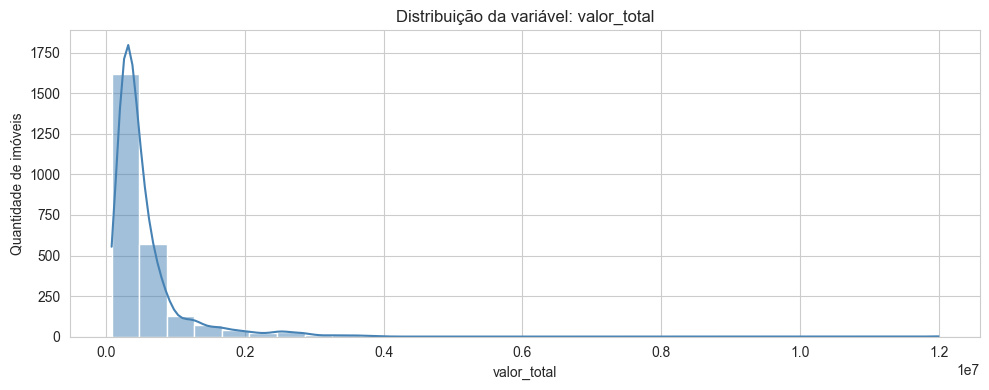

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualização da variavel Valor_total
variaveis = ["valor_total"]

# Plotar histogramas
for var in variaveis:
    plt.figure(figsize=(10, 4))
    sns.histplot(data[var], bins=30, kde=True, color="steelblue")
    plt.title(f"Distribuição da variável: {var}")
    plt.xlabel(var)
    plt.ylabel("Quantidade de imóveis")
    plt.grid(True)
    plt.tight_layout()
    plt.show()



A distribuição da variável `valor_total` é **assimétrica à direita (distribuição enviesada positivamente)**, indicando que a maioria dos imóveis está concentrada em **valores mais baixos**, enquanto poucos imóveis possuem **valores muito altos**, considerados **outliers**.

Esse comportamento é esperado em mercados urbanos, onde há uma grande quantidade de imóveis populares e uma minoria de imóveis de alto padrão que elevam a média geral.

Essa informação é útil para **segmentar análises por faixa de preço** e para compradores que desejam compreender onde está a maior concentração de imóveis dentro do mercado.


<h3>Distribuição da Área Útil dos Imóveis (m²)</h3>

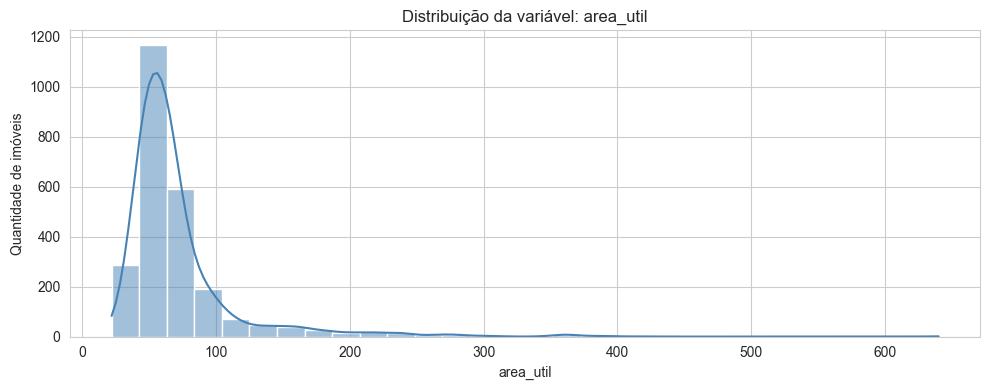

In [96]:
# Visualização da variável de area Util
variaveis = ["area_util"]

# Plotar histogramas
for var in variaveis:
    plt.figure(figsize=(10, 4))
    sns.histplot(data[var], bins=30, kde=True, color="steelblue")
    plt.title(f"Distribuição da variável: {var}")
    plt.xlabel(var)
    plt.ylabel("Quantidade de imóveis")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


A variável `area_util` também apresenta uma **distribuição assimétrica à direita**, indicando que a maioria dos imóveis possui **áreas entre 40 e 100 m²**, enquanto poucas unidades têm áreas superiores a 200 m², sendo essas consideradas **outliers (imóveis de alto padrão)**.

Essa concentração em áreas menores sugere um mercado predominantemente voltado para **apartamentos compactos**, o que pode refletir o perfil de compradores, a urbanização densa de São Paulo e o foco em acessibilidade e praticidade.

Essa informação é relevante tanto para **construtoras e incorporadoras**, que podem entender a faixa de maior demanda, quanto para **compradores**, que desejam se posicionar dentro de um padrão médio de área.


<h3>Distribuição do Valor por Metro Quadrado (R$)</h3>

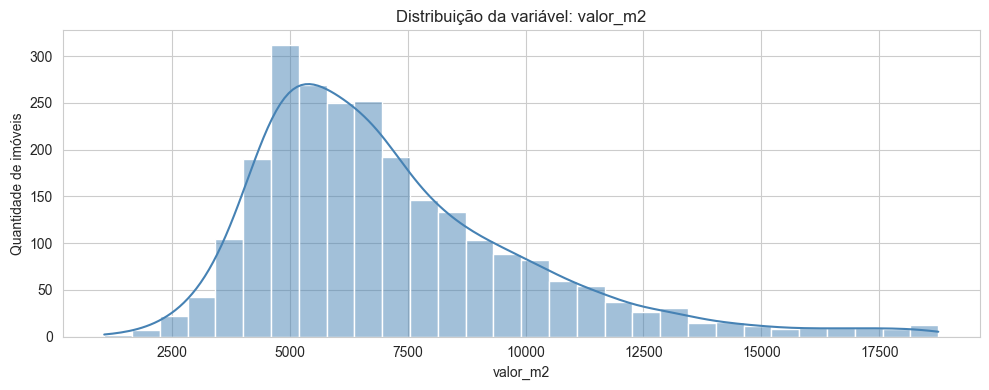

In [103]:
# Visualização da variável valor_m2
variaveis = ["valor_m2"]

# Plotar histogramas
for var in variaveis:
    plt.figure(figsize=(10, 4))
    sns.histplot(data[var], bins=30, kde=True, color="steelblue")
    plt.title(f"Distribuição da variável: {var}")
    plt.xlabel(var)
    plt.ylabel("Quantidade de imóveis")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

A variável `valor_m2` apresenta uma **distribuição assimétrica à direita**, com a maior concentração de imóveis na faixa de **R$ 4.000 a R$ 7.000 por metro quadrado**. Há uma cauda longa indicando a presença de **imóveis com preços muito acima da média**, que podem ser classificados como **de alto padrão ou localizados em regiões extremamente valorizadas**.

Essa análise é crucial para entender o comportamento do mercado em termos de **valorização territorial** e **acessibilidade**. Imóveis com valor por m² elevado estão geralmente associados a bairros com **melhor infraestrutura, IDH mais alto e proximidade com transporte público**.

Essas informações são valiosas para:
- **Compradores** avaliarem o custo-benefício do metro quadrado;
- **Vendedores e investidores** ajustarem suas estratégias de precificação;
- E **gestores públicos** entenderem a desigualdade espacial no mercado imobiliário.


<h3>Quantidade de Quartos nos Imóveis</h3>

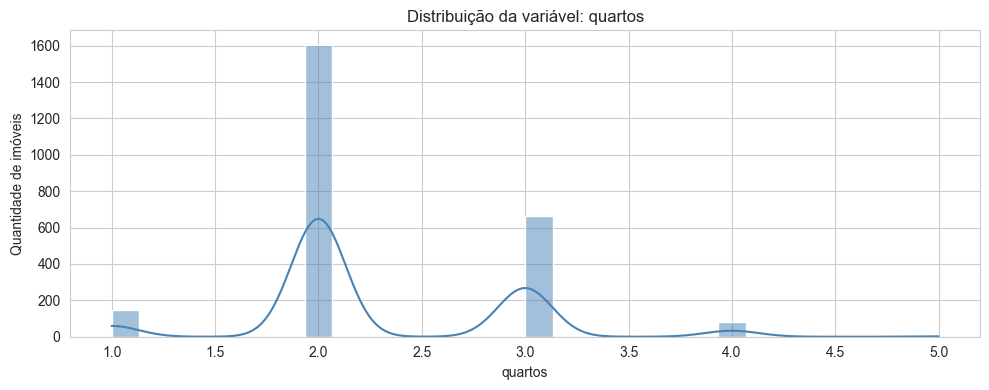

In [102]:
# Visualização da variável quartos
variaveis = ["quartos"]

# Plotar histogramas
for var in variaveis:
    plt.figure(figsize=(10, 4))
    sns.histplot(data[var], bins=30, kde=True, color="steelblue")
    plt.title(f"Distribuição da variável: {var}")
    plt.xlabel(var)
    plt.ylabel("Quantidade de imóveis")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

A variável `quartos` apresenta uma **distribuição discreta e multimodal**, com **picos bem definidos** nos imóveis com **2 e 3 quartos**. O maior volume de imóveis disponíveis tem **2 quartos**, seguido por imóveis com **3 quartos**, enquanto imóveis com apenas **1 ou 4 quartos** são menos frequentes, e imóveis com **5 quartos ou mais** são raríssimos.

Essa distribuição reflete o padrão de mercado voltado para **famílias pequenas ou casais**, sendo o tipo mais comum de imóvel aquele com **2 dormitórios**, o que pode indicar:
- Maior facilidade de comercialização;
- Perfil demográfico urbano predominante;
- Ou até foco das construtoras na **classe média**.

Essa informação é útil para **planejamento de lançamentos imobiliários**, **análise de demanda regional** e para que **compradores avaliem as opções predominantes disponíveis no mercado**.


<h3>Quantidade de Vagas de Garagem</h3>

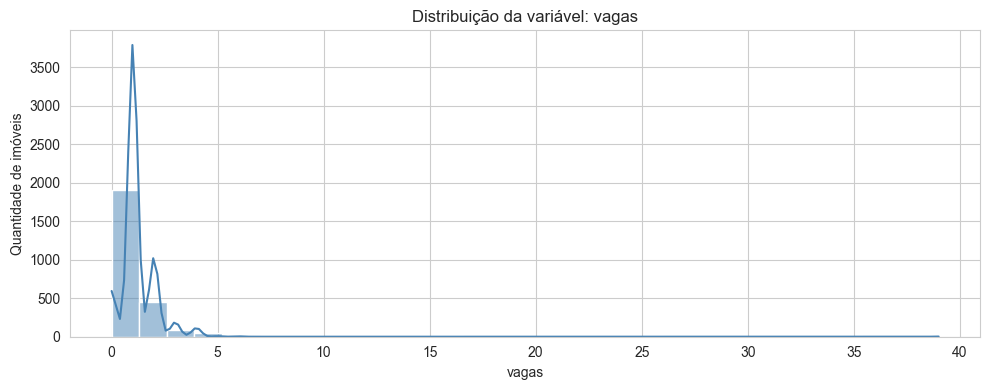

In [106]:
# Visualização da variável vagas
variaveis = ["vagas"]

# Plotar histogramas
for var in variaveis:
    plt.figure(figsize=(10, 4))
    sns.histplot(data[var], bins=30, kde=True, color="steelblue")
    plt.title(f"Distribuição da variável: {var}")
    plt.xlabel(var)
    plt.ylabel("Quantidade de imóveis")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

A variável `vagas` apresenta uma **distribuição extremamente assimétrica à direita**, com a **maioria dos imóveis oferecendo entre 1 e 2 vagas de garagem**. Há um pequeno grupo de imóveis com 3 ou mais vagas e **alguns valores extremos**, chegando a até **38 vagas**, o que provavelmente representa imóveis comerciais, coberturas ou residenciais de alto luxo.

Essa distribuição indica que o mercado é fortemente voltado para **usuários que possuem até dois veículos**, o que é coerente com o perfil urbano e familiar predominante nas grandes cidades. Os outliers, embora raros, são relevantes para análises específicas de mercado de alto padrão.

Essas informações são importantes para:
- Avaliar o perfil dos imóveis disponíveis;
- Cruzar com o valor por metro quadrado;
- Identificar padrões de valorização atrelados à disponibilidade de garagem.


<h3>Quantidade de Banheiros nos Imóveis</h3>

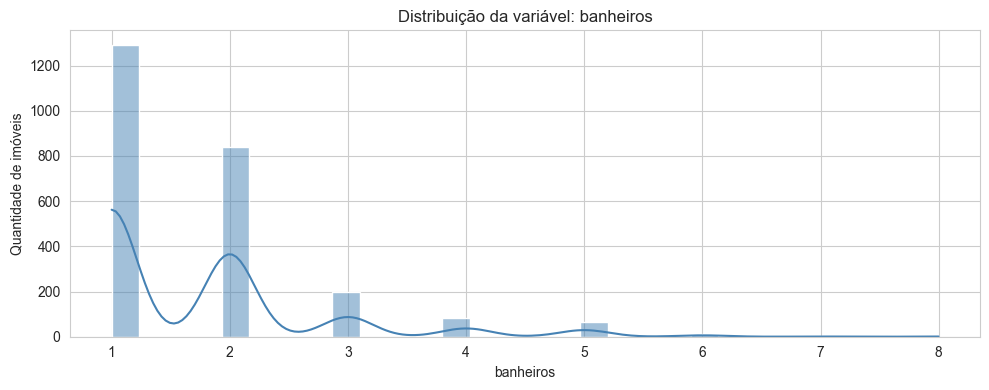

In [109]:
# Visualização da variável banheiros
variaveis = ["banheiros"]

# Plotar histogramas
for var in variaveis:
    plt.figure(figsize=(10, 4))
    sns.histplot(data[var], bins=30, kde=True, color="steelblue")
    plt.title(f"Distribuição da variável: {var}")
    plt.xlabel(var)
    plt.ylabel("Quantidade de imóveis")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

A distribuição da variável `banheiros` é discreta e fortemente assimétrica à direita, com destaque para imóveis com **1 e 2 banheiros**, que representam a maior parte do conjunto de dados. A frequência cai significativamente a partir de 3 banheiros, embora ainda haja uma quantidade considerável de imóveis com até 5 banheiros.

Esse padrão está alinhado com o perfil dos imóveis residenciais urbanos voltados para **famílias pequenas ou médias**, e mostra que a oferta de imóveis com 4 ou mais banheiros é voltada para nichos mais específicos, como imóveis maiores ou de alto padrão.

Essa informação é útil para entender:
- A **padronização da oferta imobiliária**,
- A relação com o **número de quartos ou suítes**,
- E possíveis **segmentações de mercado** com base na infraestrutura interna dos imóveis.


<h3>Distribuição dos Valores de Condomínio (R$)</h3>

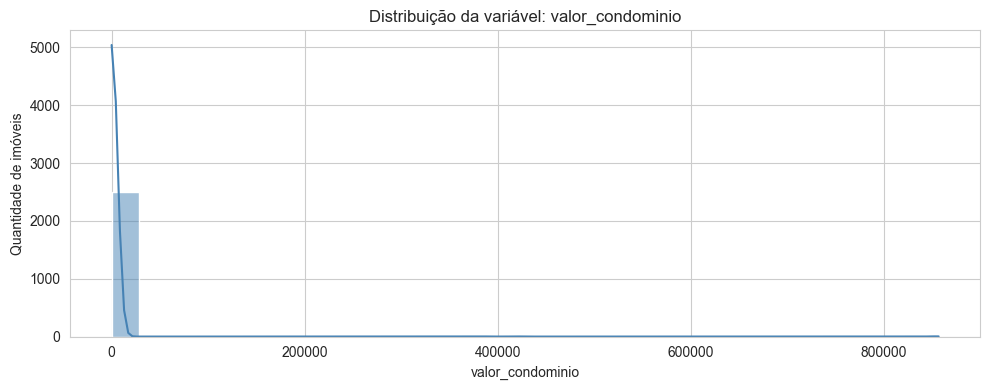

In [112]:
# Visualização da variável valor_condominio
variaveis = ["valor_condominio"]

# Plotar histogramas
for var in variaveis:
    plt.figure(figsize=(10, 4))
    sns.histplot(data[var], bins=30, kde=True, color="steelblue")
    plt.title(f"Distribuição da variável: {var}")
    plt.xlabel(var)
    plt.ylabel("Quantidade de imóveis")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

A variável `valor_condominio` apresenta uma **distribuição extremamente assimétrica à direita**, com a grande maioria dos imóveis concentrada em valores de condomínio **abaixo de R$ 2.000,00** . No entanto, há **valores extremamente altos** , que ultrapassam **R$ 800.000**, representando casos atípicos ou possíveis erros de digitação e inconsistências resultantes da coleta via web scraping.

Esses outliers influenciam fortemente a média e devem ser analisados com cautela ou tratados previamente em análises mais específicas. Ainda assim, a distribuição geral reforça que a maioria dos imóveis se enquadra em **faixas de condomínio compatíveis com o mercado residencial urbano de classe média e média-alta**.

Essa variável é especialmente importante para:
- **Comparar o custo total da moradia além do valor de venda**;
- Investigar a relação entre **valor do condomínio e infraestrutura disponível no imóvel (piscina, academia, etc.)**;
- E identificar possíveis erros ou valores fora da curva no processo de extração dos dados.


<br><h3>Análises Comparativas</h3>

### 💡 Valor por m² por Faixa de IDH


Nesta seção, buscamos entender se existe uma **relação entre o valor do metro quadrado dos imóveis** e o **nível de desenvolvimento humano dos bairros** em que estão localizados.

Para isso, foi criada a variável `faixa_idh`, que classifica os bairros com base em intervalos padronizados do **Índice de Desenvolvimento Humano (IDH)**, agrupando-os em categorias como "Muito Baixo", "Baixo", "Médio", "Alto" e "Muito Alto".

O gráfico a seguir apresenta a **distribuição do valor por m² (R$)** dentro de cada faixa de IDH, permitindo identificar padrões de valorização relacionados à qualidade de vida da região.

Esse tipo de análise é útil para:
- **Investidores** que buscam regiões com maior valorização;
- **Gestores públicos** interessados em mapear desigualdades socioespaciais;
- E **compradores**, que podem avaliar o custo-benefício dos imóveis em diferentes contextos urbanos.

In [125]:
# Definir os intervalos de IDH e os respectivos rótulos
bins_idh = [0.6, 0.7, 0.75, 0.8, 0.85, 0.95]
labels_idh = ['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Muito Alto']

# Criar nova coluna categorizando o IDH
data["faixa_idh"] = pd.cut(data["media_idh"], bins=bins_idh, labels=labels_idh)


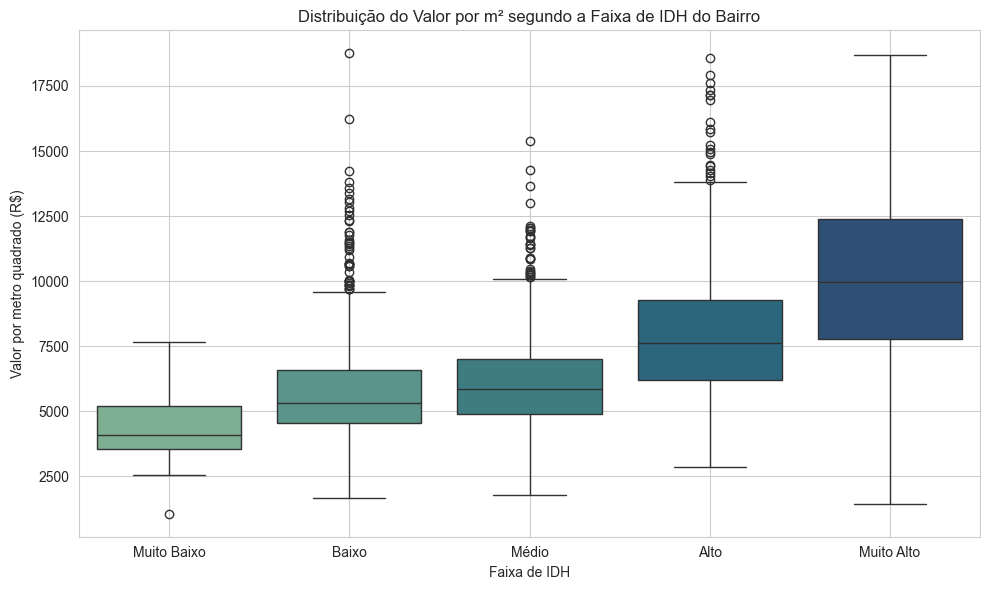

In [132]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="faixa_idh",
    y="valor_m2",
    data=data,
    hue="faixa_idh",         # adiciona a categoria como hue (exige em versões futuras)
    palette="crest",
    legend=False             # evita que a legenda se repita
)
plt.title("Distribuição do Valor por m² segundo a Faixa de IDH do Bairro")
plt.xlabel("Faixa de IDH")
plt.ylabel("Valor por metro quadrado (R$)")
plt.grid(True)
plt.tight_layout()
plt.show()


O gráfico acima mostra a distribuição do valor por metro quadrado (`valor_m2`) em diferentes **faixas de IDH** (Índice de Desenvolvimento Humano) dos bairros.

É possível observar que **bairros com IDH mais elevado** tendem a apresentar **valores medianos de m² significativamente maiores**, o que reforça a correlação entre **qualidade de vida e valorização imobiliária**.

Essa análise evidencia que o IDH é um forte indicador de mercado, sendo útil para:
- Investidores que buscam regiões de alta valorização;
- Políticas públicas voltadas à equidade territorial;
- E compradores que desejam avaliar custo-benefício considerando infraestrutura e qualidade de vida.


### 💡 Valor por m² vs. Expectativa de Vida

Essa análise permite identificar se bairros com maior expectativa de vida também apresentam valores imobiliários mais altos, o que ajuda a compreender relações entre saúde, infraestrutura urbana e valorização.



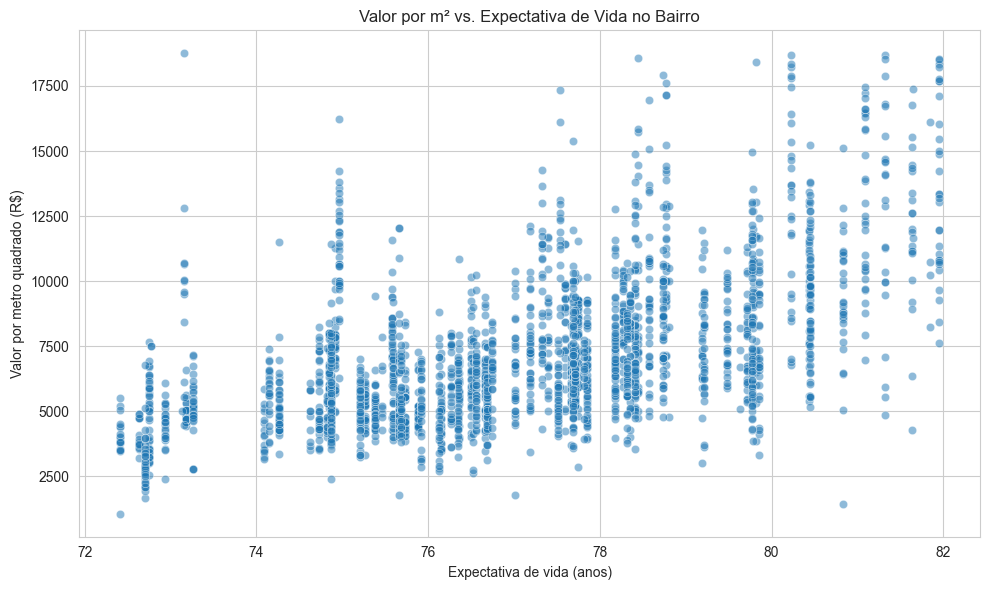

In [133]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="expectativa_vida", y="valor_m2", data=data, alpha=0.5)
plt.title("Valor por m² vs. Expectativa de Vida no Bairro")
plt.xlabel("Expectativa de vida (anos)")
plt.ylabel("Valor por metro quadrado (R$)")
plt.grid(True)
plt.tight_layout()
plt.show()


O gráfico de dispersão mostra como o valor por metro quadrado (`valor_m2`) se comporta em relação à **expectativa de vida nos bairros**.

Percebe-se uma tendência de **valores mais elevados de m² em regiões com maior expectativa de vida**, o que sugere que o mercado imobiliário acompanha **níveis de qualidade de vida e infraestrutura urbana**.

Essa correlação é importante para:
- Compreender desigualdades socioespaciais;
- Avaliar oportunidades de investimento em regiões valorizadas;
- Apoiar políticas públicas voltadas à moradia em áreas menos favorecidas.

### 💡 Valor por m² vs. Distância até a estação de metrô

Nesta seção, analisamos a relação entre o **valor por metro quadrado dos imóveis (`valor_m2`)** e a **distância até a estação de metrô mais próxima (`dist`)**.

A proximidade com o transporte público é um dos principais fatores de valorização imobiliária em grandes cidades como São Paulo. Imóveis localizados próximos a estações tendem a ser mais atrativos por conta da **facilidade de locomoção**, **redução do tempo de deslocamento** e acesso mais rápido a regiões centrais.

Ao limitar a análise aos imóveis com até **5.000 metros de distância do metrô**, buscamos compreender com mais clareza como essa variável influencia o valor dos imóveis. O gráfico de dispersão a seguir ajuda a visualizar se existe essa correlação e até onde ela é mais significativa.

In [137]:
##Filtrar para até 5 km do metrô (para melhor visualização)
data_filtrada = data[data["dist"] <= 5000]

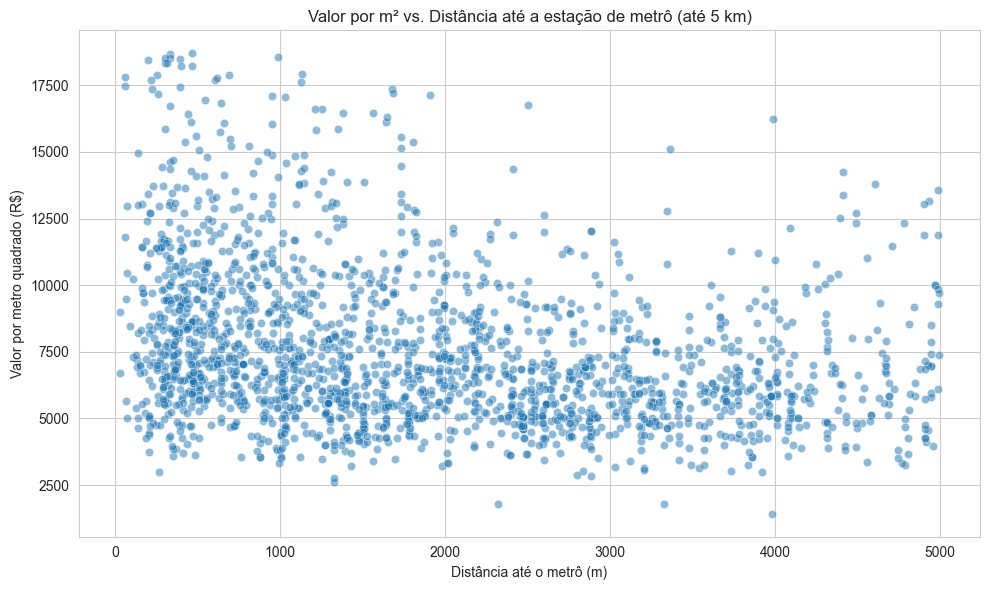

In [139]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="dist", y="valor_m2", data=data_filtrada, alpha=0.5)
plt.title("Valor por m² vs. Distância até a estação de metrô (até 5 km)")
plt.xlabel("Distância até o metrô (m)")
plt.ylabel("Valor por metro quadrado (R$)")
plt.grid(True)
plt.tight_layout()
plt.show()


O gráfico de dispersão demonstra a relação entre a **distância até a estação de metrô** (`dist`) e o **valor por metro quadrado** (`valor_m2`) dos imóveis analisados.

Observa-se uma **concentração significativa de imóveis com valor por m² mais alto em regiões até 1.000 metros das estações**. À medida que a distância aumenta, o valor por m² tende a diminuir gradualmente, com uma dispersão maior e valores mais baixos predominando a partir dos 2.000 metros.

Essa tendência indica que a **proximidade com o metrô tem um impacto direto na valorização dos imóveis**, tornando a localização um dos principais fatores determinantes de preço.

Essa análise é relevante para:
- **Compradores e investidores** que buscam imóveis valorizados e bem localizados;
- **Planejadores urbanos** que desejam entender como a infraestrutura influencia o mercado;
- E **políticas públicas de mobilidade urbana**, visando integrar áreas mais afastadas com transporte de qualidade.

### 💰 Valor por m² vs. Renda Per Capita

Nesta seção, analisamos a relação entre o **valor por metro quadrado** dos imóveis e a **renda média per capita dos bairros** onde estão localizados.

A variável `renda_percapita` é um indicador importante do **nível socioeconômico da região** e, portanto, pode influenciar diretamente o comportamento do mercado imobiliário. Ao visualizar essa relação, buscamos entender como a renda afeta a valorização dos imóveis em São Paulo.

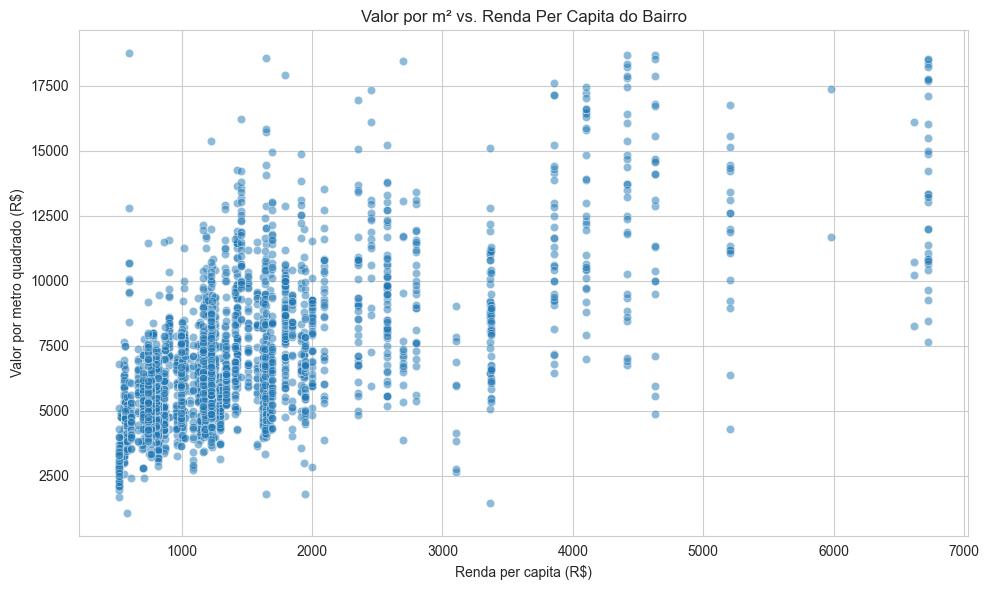

In [141]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="renda_percapita", y="valor_m2", data=data, alpha=0.5)
plt.title("Valor por m² vs. Renda Per Capita do Bairro")
plt.xlabel("Renda per capita (R$)")
plt.ylabel("Valor por metro quadrado (R$)")
plt.grid(True)
plt.tight_layout()
plt.show()


O gráfico de dispersão mostra uma relação positiva entre a **renda média per capita dos bairros** e o **valor por metro quadrado dos imóveis**.

Nota-se que os **maiores valores de m²** estão concentrados em **bairros com renda per capita superior a R$ 3.000**, o que indica que a **capacidade financeira da população local** influencia diretamente a valorização imobiliária.

Apesar de alguma dispersão natural dos dados, a tendência geral confirma que regiões com **maior poder aquisitivo** tendem a ter imóveis mais caros por metro quadrado — um padrão esperado, mas agora visivelmente comprovado no conjunto de dados.

Essa relação é útil para:
- **Investidores** entenderem o perfil socioeconômico de regiões promissoras;
- **Gestores públicos** mapearem desigualdades espaciais no acesso à moradia;
- E **compradores** avaliarem o equilíbrio entre valor do imóvel e renda média local.

### 📍 Valor por m² nos Bairros mais Valorizados








Nesta seção, analisamos os **10 bairros com maior valor médio por metro quadrado** (`valor_m2`). Essa análise nos permite identificar as **regiões mais valorizadas da cidade**, que normalmente combinam fatores como:

- Alta renda per capita,
- Boa infraestrutura urbana,
- Proximidade com transporte público,
- Alto IDH e qualidade de vida.

Esse tipo de informação é útil para:
- **Investidores e incorporadoras** que buscam áreas premium;
- **Planejamento urbano e políticas públicas**;
- E para **compradores** que desejam comparar diferentes regiões de forma estratégica.






In [144]:
media_valor_bairro = data.groupby("bairro")["valor_m2"].mean().sort_values(ascending=False).head(10)


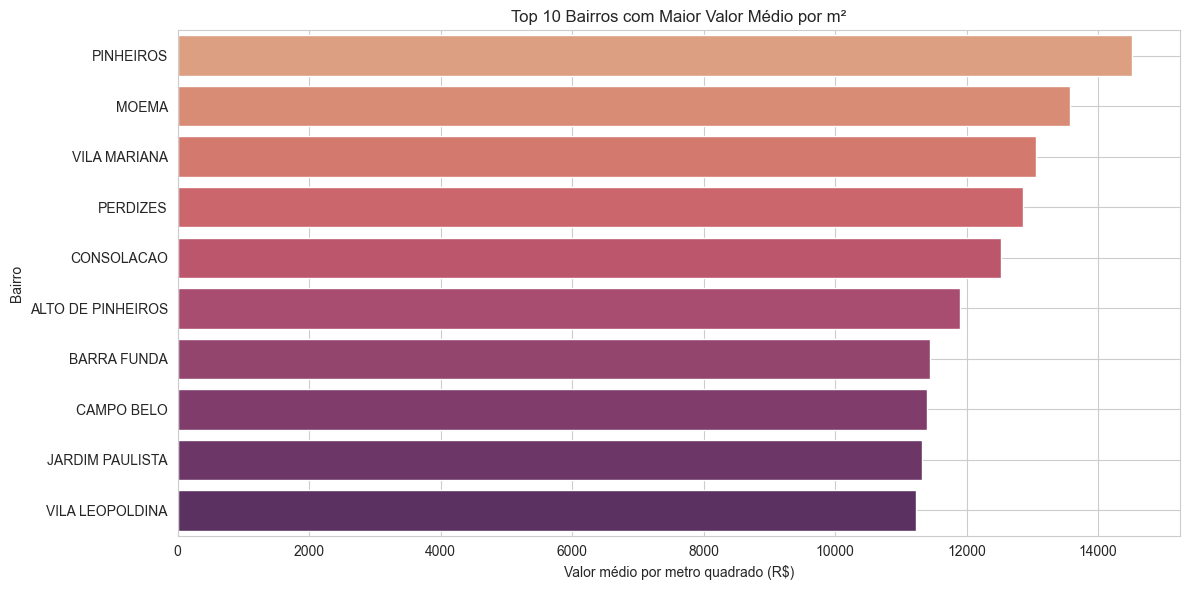

In [147]:
plt.figure(figsize=(12, 6))
sns.barplot(
    x=media_valor_bairro.values,
    y=media_valor_bairro.index,
    hue=media_valor_bairro.index,  # Adiciona hue com a mesma informação do eixo y
    palette="flare",
    legend=False
)
plt.title("Top 10 Bairros com Maior Valor Médio por m²")
plt.xlabel("Valor médio por metro quadrado (R$)")
plt.ylabel("Bairro")
plt.grid(True)
plt.tight_layout()
plt.show()





O gráfico acima apresenta os 10 bairros com **maior valor médio por m²** na cidade de São Paulo. Em destaque, temos bairros como **Pinheiros, Moema e Vila Mariana**, que lideram o ranking com valores médios que ultrapassam os **R$ 12.000 por metro quadrado**.

Esses bairros estão associados a características como:
- **Alta renda per capita**;
- **Boa infraestrutura urbana**;
- **Localização privilegiada**, próxima a estações de metrô, centros comerciais e áreas de lazer;
- E **alta qualidade de vida**, refletida em índices como IDH e expectativa de vida.

Essa análise ajuda a compreender:
- Onde estão concentrados os **imóveis de alto padrão**;
- Como a localização influencia o preço por m²;
- E fornece informações valiosas para **tomada de decisão por parte de compradores, investidores e gestores públicos**.

A visualização também reforça a presença de **desigualdades espaciais**, já que o valor por m² pode variar bastante entre regiões da cidade.


### 🏘️ Bairros com Menor Valor Médio por Metro Quadrado

Este gráfico apresenta os 10 bairros com **menor valor médio por metro quadrado (R$)**, ou seja, **as regiões com imóveis mais acessíveis** dentro da cidade de São Paulo.

Entre os bairros com menor valorização destacam-se **Lajeado, Grajaú e Cidade Tiradentes**, que possuem valores por m² significativamente abaixo da média geral da cidade.

Esses bairros, em geral, apresentam:
- **Menor renda per capita**;
- **Maior distância de estações de metrô ou centros comerciais**;
- E **índices de desenvolvimento humano (IDH) e expectativa de vida mais baixos**, como observado em análises anteriores.

Essa visualização reforça a importância de políticas públicas de:
- **Habitação popular**,
- **Melhoria da infraestrutura urbana em regiões periféricas**,
- E **redução das desigualdades socioespaciais** no acesso à moradia digna.

Também pode ser útil para **investidores** que buscam áreas com potencial de crescimento futuro e valorização ao longo do tempo.

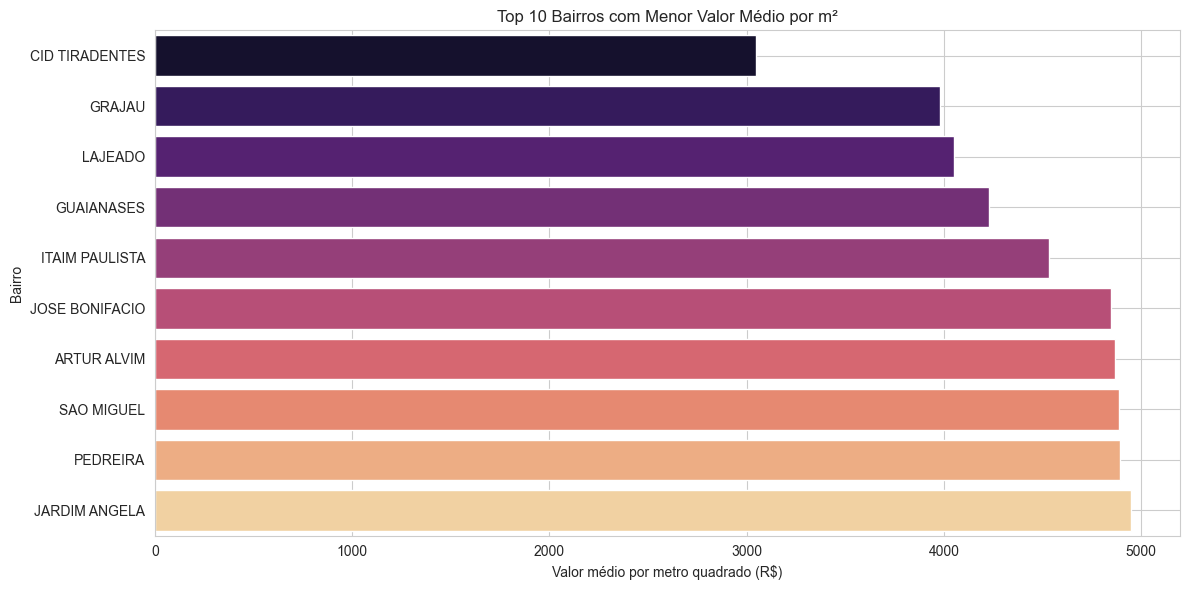

In [150]:
# Agrupar por bairro e pegar os 10 com menor valor médio por m²
bairros_menos_valorizados = data.groupby("bairro")["valor_m2"].mean().sort_values(ascending=True).head(10)

# Criar gráfico de barras horizontal
plt.figure(figsize=(12, 6))
sns.barplot(
    x=bairros_menos_valorizados.values,
    y=bairros_menos_valorizados.index,
    hue=bairros_menos_valorizados.index,  # necessário para evitar o FutureWarning
    palette="magma",
    legend=False                          # evita legenda repetida
)
plt.title("Top 10 Bairros com Menor Valor Médio por m²")
plt.xlabel("Valor médio por metro quadrado (R$)")
plt.ylabel("Bairro")
plt.grid(True)
plt.tight_layout()
plt.show()



## ✅ Conclusão e Principais Insights

Este trabalho apresentou uma análise descritiva e exploratória de um conjunto de dados sobre **apartamentos à venda em São Paulo**, com o objetivo de compreender o comportamento do mercado imobiliário e identificar fatores que influenciam o **valor por metro quadrado (R$/m²)**.

As análises incluíram estatísticas básicas, visualizações e comparativos relevantes, considerando variáveis socioeconômicas, infraestrutura e localização. A seguir, destacam-se os **principais insights encontrados**:

🔹 **Valor do metro quadrado** apresenta forte correlação com:
- **IDH dos bairros** — quanto maior o índice, maior o valor médio do m²;
- **Expectativa de vida** — bairros com maior qualidade de vida concentram imóveis mais caros;
- **Renda per capita** — regiões mais ricas apresentam imóveis de maior valor por m²;
- **Proximidade com o metrô** — imóveis até 1.000m da estação tendem a ser mais valorizados.

🔹 Os **bairros mais valorizados** incluem:
`Pinheiros`, `Moema`, `Vila Mariana` e `Perdizes`.

🔹 Os **bairros mais acessíveis** (menor valor por m²) incluem:
`Lajeado`, `Cidade Tiradentes`, `Grajaú` e `Jardim Helena`.

🔹 A maioria dos imóveis ofertados tem:
- **2 quartos**,
- **1 a 2 banheiros**,
- **1 vaga de garagem**,
- E área útil entre **40 e 80 m²**.

---

### 🎯 Considerações finais:

Essas análises fornecem uma visão clara e prática para **compradores, vendedores, investidores e gestores públicos**, permitindo:
- Avaliar oportunidades e riscos no mercado imobiliário;
- Planejar estratégias de expansão e investimento;
- Apoiar decisões políticas voltadas à moradia, mobilidade e inclusão urbana.

A análise também evidencia **desigualdades espaciais significativas**, o que reforça a importância de políticas públicas voltadas para a equidade habitacional em grandes centros urbanos como São Paulo.

---


<br>

<br><br>